# Zomato Delivery ETA: Exploratory Data Analysis

This notebook explores delivery-time patterns, data quality, distance effects, and weather-traffic interactions in the Zomato-style delivery dataset.

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid', context='notebook')
TARGET = 'Time_taken (min)'
DATASET_NAME = 'Zomato Dataset.csv'
CATEGORICAL_COLUMNS = ['Weather_conditions', 'Road_traffic_density', 'Type_of_order', 'Type_of_vehicle', 'Festival', 'City']

Libraries imported successfully.


## 1. Basic Dataset Overview

In [2]:
candidate_paths = [
    Path('content') / DATASET_NAME,
    Path('LumiVerse/content') / DATASET_NAME,
    Path.cwd().parent / 'content' / DATASET_NAME,
]
dataset_path = next((path for path in candidate_paths if path.exists()), None)
if dataset_path is None:
    raise FileNotFoundError(f'Could not find {DATASET_NAME!r}. Checked: {candidate_paths}')

df = pd.read_csv(dataset_path)
df.columns = df.columns.str.strip()
print(f'Loaded: {dataset_path.resolve()}')
print(f'Shape: {df.shape}')
display(df.head())

Loaded: C:\Users\koush\OneDrive\Desktop\Lumiverse\LumiVerse\content\Zomato Dataset.csv
Shape: (45584, 20)


,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [3]:
print('Data types:')
display(df.dtypes.to_frame('dtype'))
print('Missing values:')
display(df.isna().sum().sort_values(ascending=False).to_frame('missing_count'))
print('Summary statistics:')
display(df.describe(include='all').T)

Data types:


,dtype
ID,str
Delivery_person_ID,str
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,str
Time_Orderd,str


Missing values:


,missing_count
Delivery_person_Ratings,1908
Delivery_person_Age,1854
Time_Orderd,1731
City,1200
multiple_deliveries,993
Weather_conditions,616
Road_traffic_density,601
Festival,228
ID,0
Delivery_person_ID,0


Summary statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,45584,45584,0xcdcd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_ID,45584,1320,JAPRES11DEL02,67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Delivery_person_Age,43730.0,NaN,NaN,NaN,29.566911,5.815064,15.0,25.0,30.0,35.0,50.0
Delivery_person_Ratings,43676.0,NaN,NaN,NaN,4.633774,0.334744,1.0,4.5,4.7,4.9,6.0
Restaurant_latitude,45584.0,NaN,NaN,NaN,17.017948,8.185674,-30.905562,12.933284,18.55144,22.728163,30.914057
Restaurant_longitude,45584.0,NaN,NaN,NaN,70.229684,22.885575,-88.366217,73.17,75.897963,78.044095,88.433452
Delivery_location_latitude,45584.0,NaN,NaN,NaN,17.46548,7.335562,0.01,12.988453,18.633934,22.785049,31.054057
Delivery_location_longitude,45584.0,NaN,NaN,NaN,70.844161,21.120578,0.01,73.28,76.002574,78.107044,88.563452
Order_Date,45584,44,15-03-2022,1192,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time_Orderd,43853,176,21:55,461,NaN,NaN,NaN,NaN,NaN,NaN,NaN


The overview confirms the dataset dimensions, data types, missingness, and scale of each feature. Missing values are retained for diagnosis before analysis-specific handling.

## 2. Target Variable Analysis

In [4]:
numeric_columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Vehicle_condition', 'multiple_deliveries', TARGET]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')
for column in CATEGORICAL_COLUMNS:
    df[column] = df[column].astype('string').str.strip().replace({'NaN': pd.NA, '': pd.NA})
analysis_df = df.dropna(subset=[TARGET]).copy()
target = analysis_df[TARGET]
q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound, upper_bound = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outlier_mask = (target < lower_bound) | (target > upper_bound)
print(f'Rows used for target analysis: {len(analysis_df):,}')
print(f'Skewness: {target.skew():.3f}')
print(f'IQR bounds: {lower_bound:.1f} to {upper_bound:.1f} minutes')
print(f'IQR outliers: {outlier_mask.sum():,} ({outlier_mask.mean():.2%})')

Rows used for target analysis: 45,584
Skewness: 0.486
IQR bounds: -0.5 to 51.5 minutes
IQR outliers: 270 (0.59%)


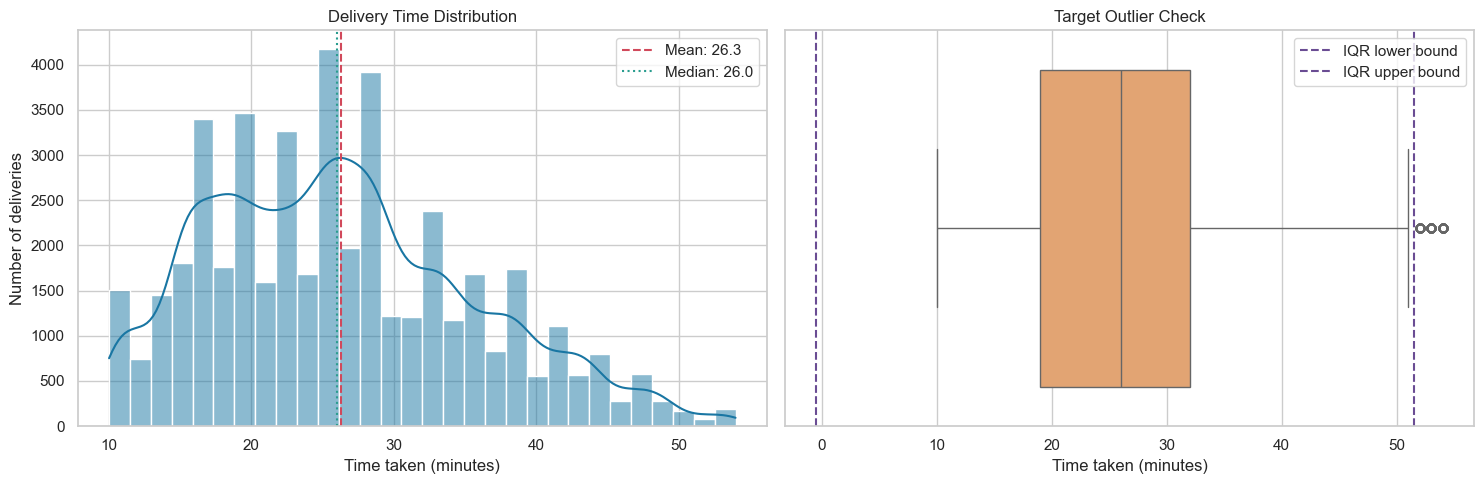

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(target, bins=30, kde=True, color='#1976a3', ax=axes[0])
axes[0].axvline(target.mean(), color='#d1495b', linestyle='--', label=f'Mean: {target.mean():.1f}')
axes[0].axvline(target.median(), color='#2a9d8f', linestyle=':', label=f'Median: {target.median():.1f}')
axes[0].set(title='Delivery Time Distribution', xlabel='Time taken (minutes)', ylabel='Number of deliveries')
axes[0].legend()
sns.boxplot(x=target, color='#f4a261', ax=axes[1])
axes[1].axvline(lower_bound, color='#6a4c93', linestyle='--', label='IQR lower bound')
axes[1].axvline(upper_bound, color='#6a4c93', linestyle='--', label='IQR upper bound')
axes[1].set(title='Target Outlier Check', xlabel='Time taken (minutes)')
axes[1].legend()
fig.tight_layout()
plt.show()

The histogram and KDE show the central delivery-time concentration and tail shape, while the boxplot quantifies extreme values using the IQR rule. Skewness and outlier share support robust metrics and models that can capture non-linear effects.

## 3. Univariate Analysis

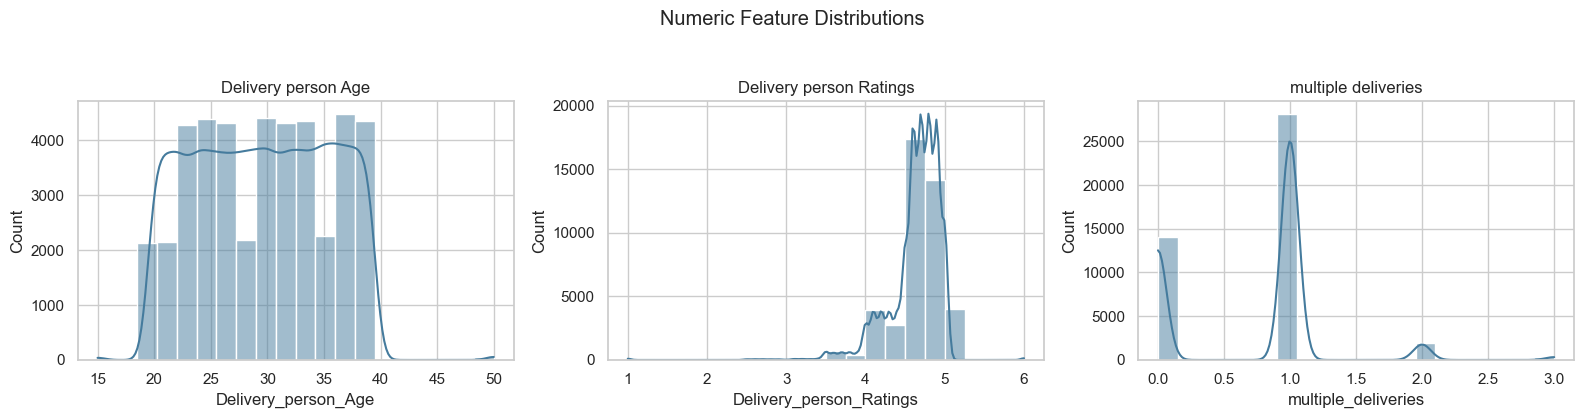

In [6]:
key_numeric = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for column, axis in zip(key_numeric, axes):
    sns.histplot(analysis_df[column].dropna(), bins=20, kde=True, color='#457b9d', ax=axis)
    axis.set(title=column.replace('_', ' '), xlabel=column, ylabel='Count')
fig.suptitle('Numeric Feature Distributions', y=1.04)
fig.tight_layout()
plt.show()

Age, ratings, and multiple deliveries show concentration and possible tails. These shapes favor flexible models or explicit preprocessing over assumptions of normality.

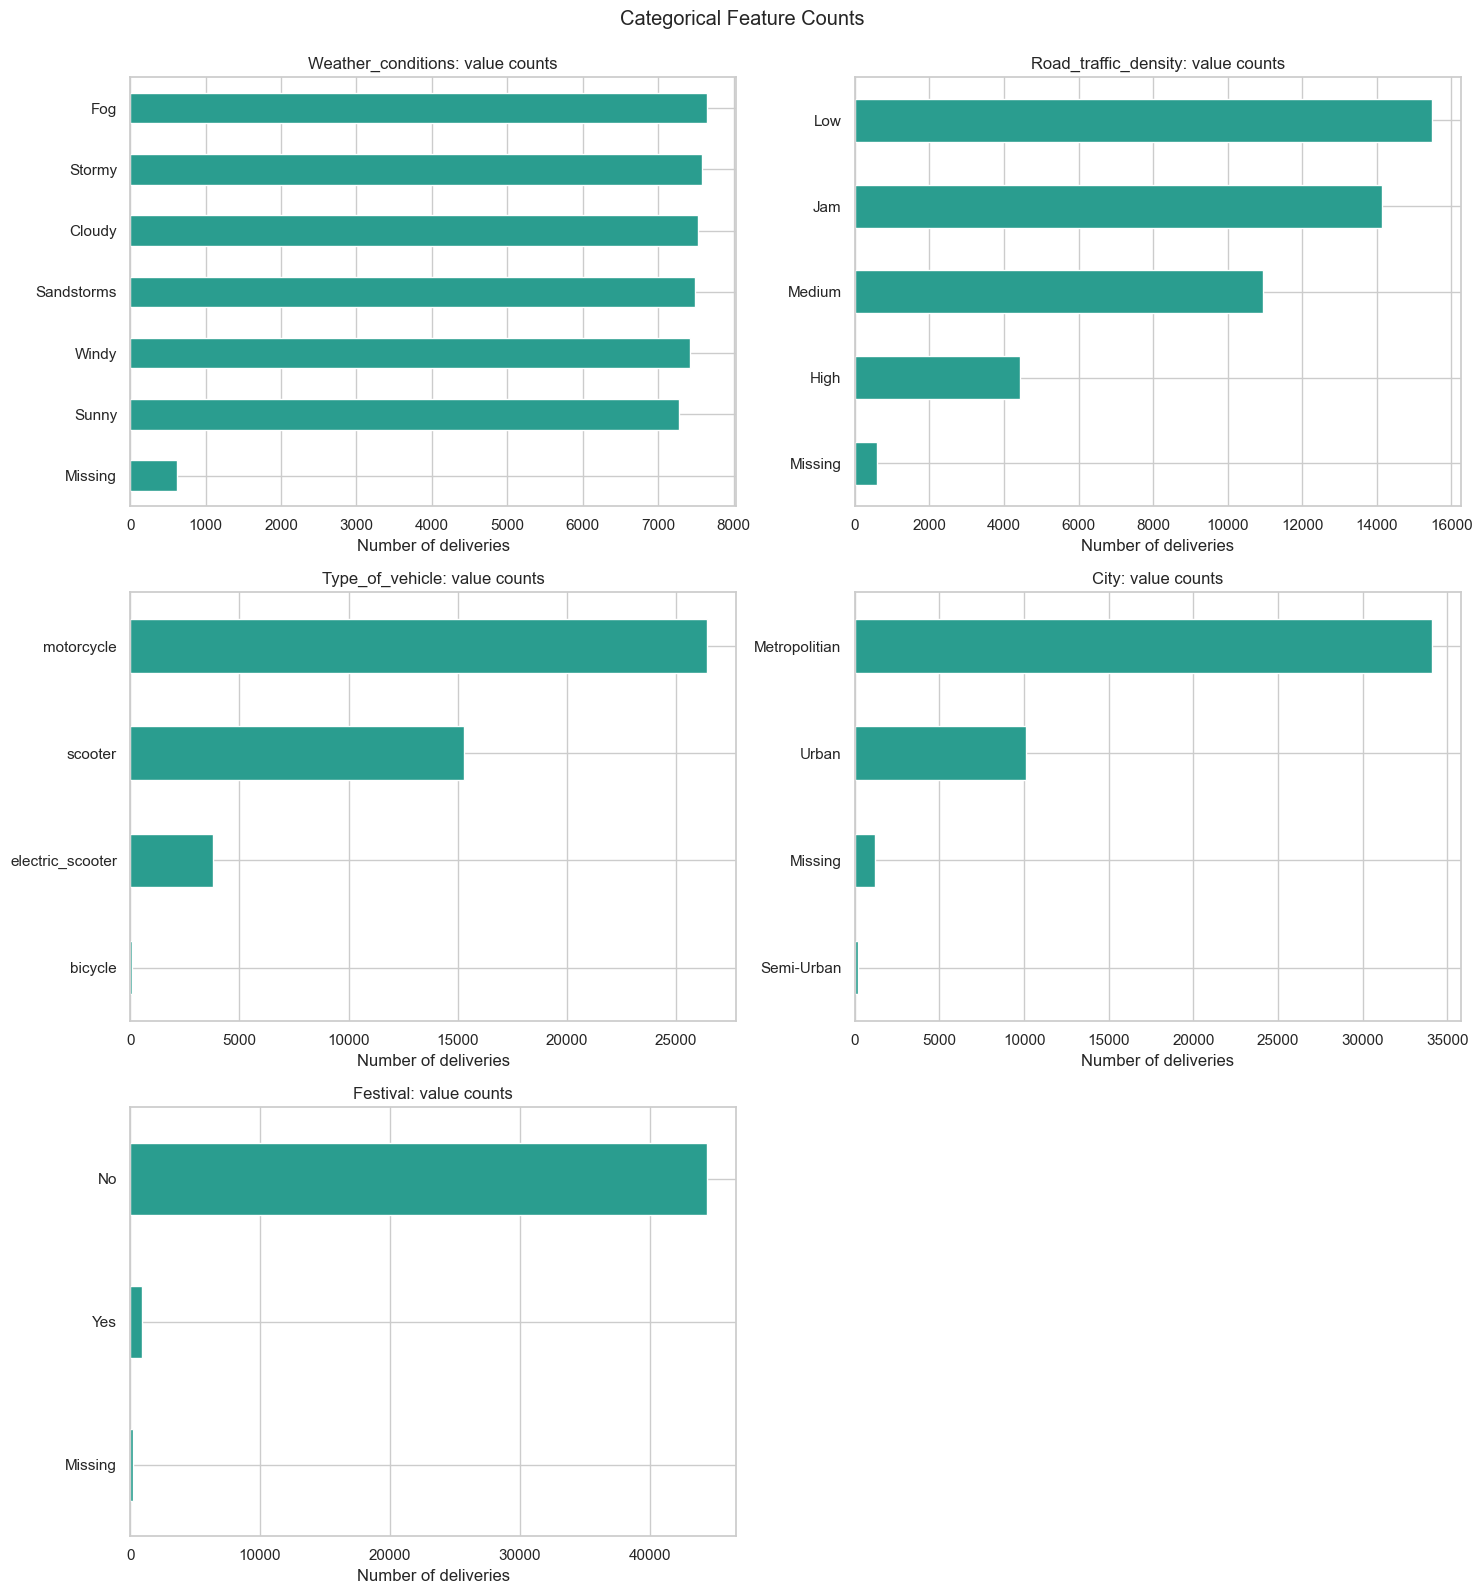

In [7]:
count_columns = ['Weather_conditions', 'Road_traffic_density', 'Type_of_vehicle', 'City', 'Festival']
fig, axes = plt.subplots(3, 2, figsize=(15, 16))
for column, axis in zip(count_columns, axes.flat):
    counts = analysis_df[column].fillna('Missing').value_counts().sort_values()
    counts.plot.barh(ax=axis, color='#2a9d8f')
    axis.set(title=f'{column}: value counts', xlabel='Number of deliveries', ylabel='')
axes.flat[-1].axis('off')
fig.suptitle('Categorical Feature Counts', y=0.995)
fig.tight_layout()
plt.show()

The count plots expose dominant and rare levels. Sparse categories may need grouping or regularized encoding, while dominant categories should not automatically be interpreted as causal.

## 4. Bivariate Analysis

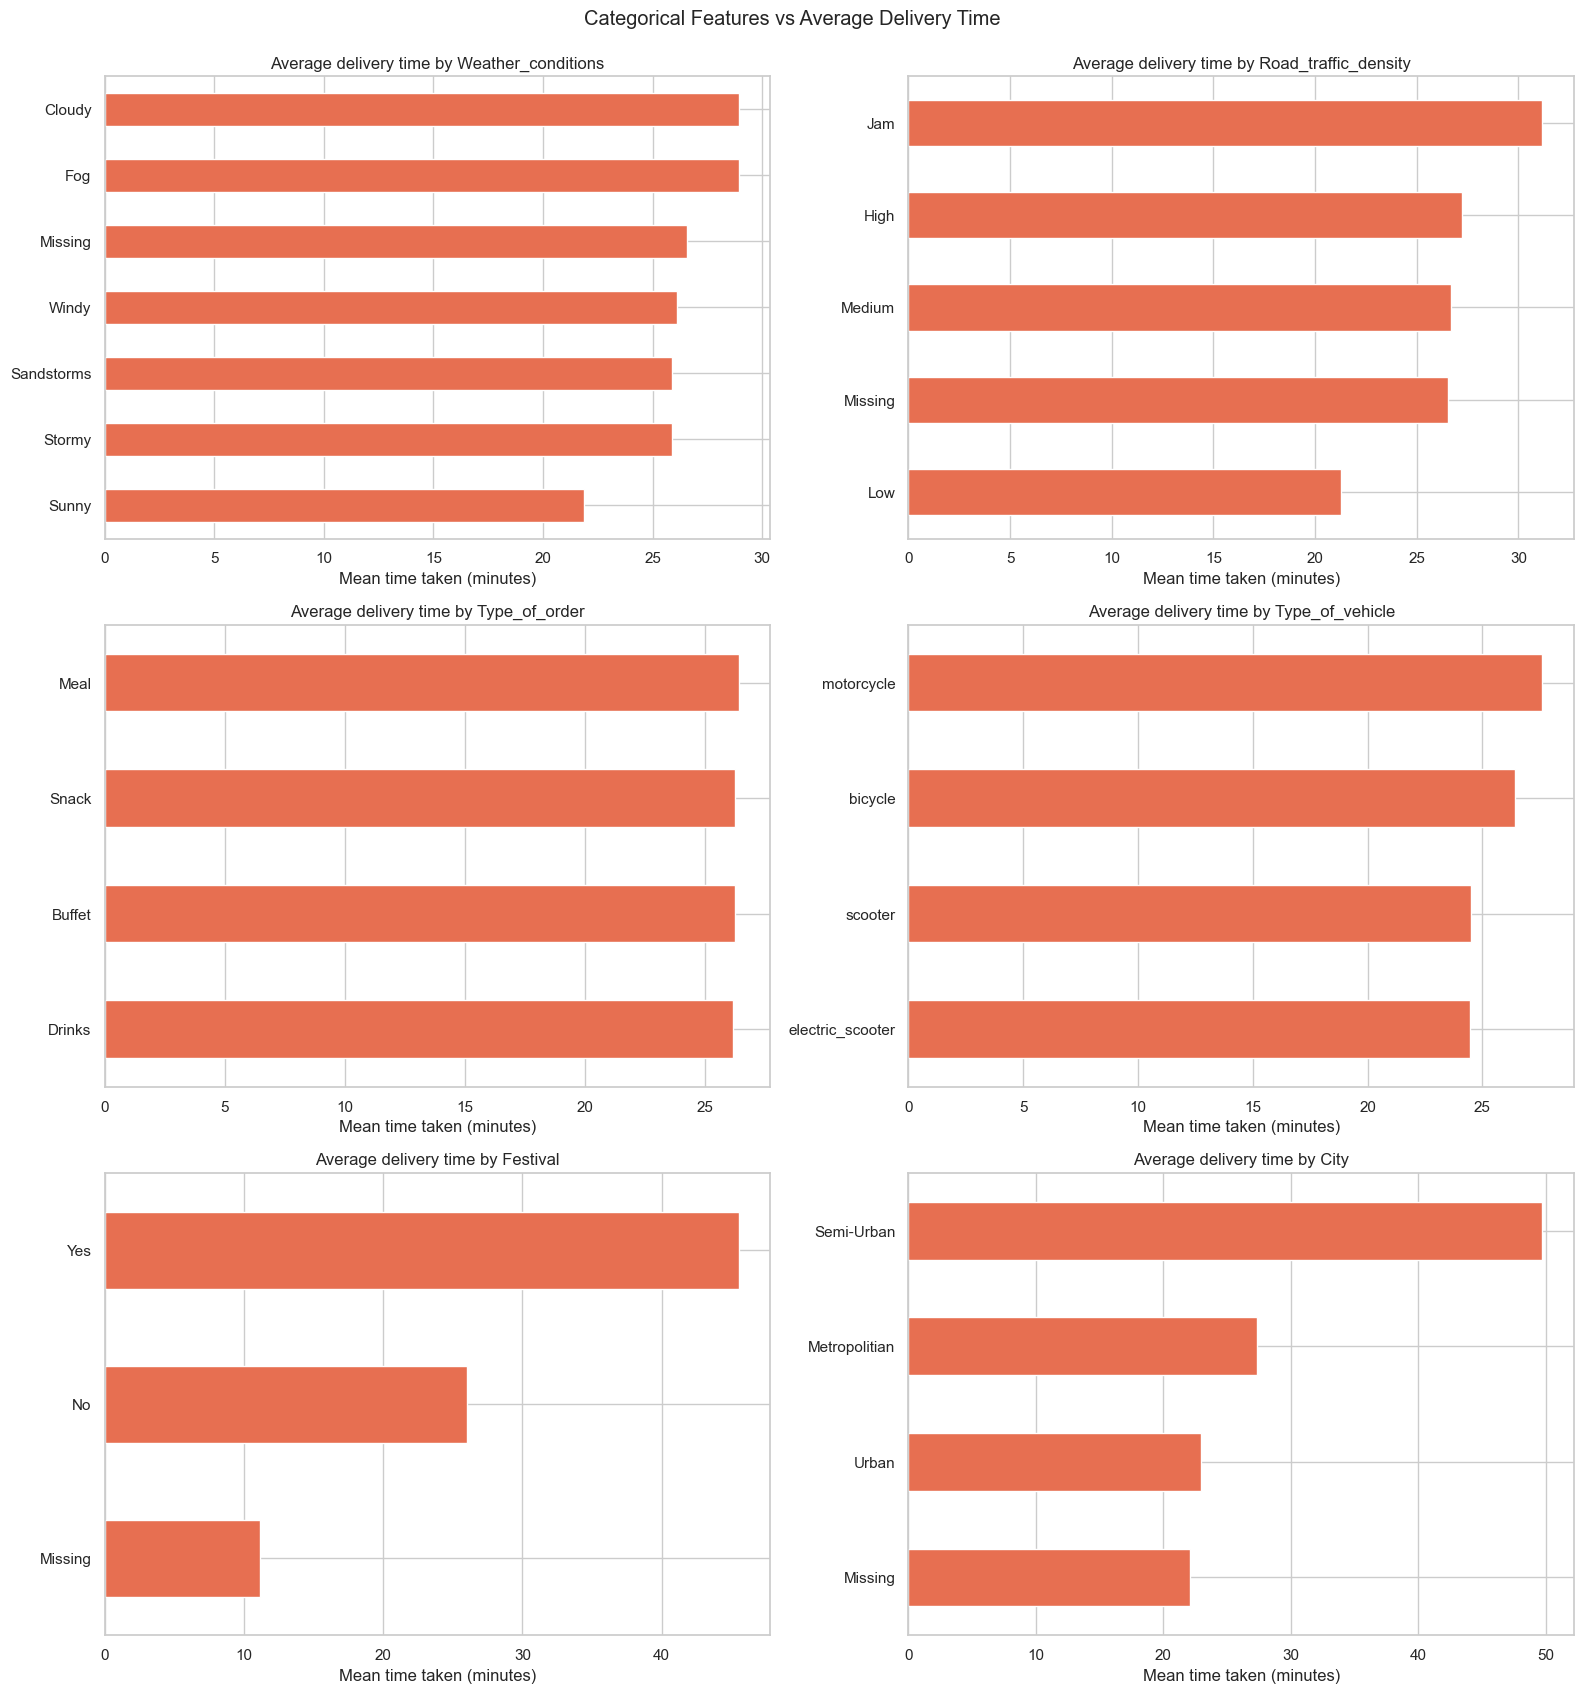

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(16, 17))
for column, axis in zip(CATEGORICAL_COLUMNS, axes.flat):
    means = (analysis_df.assign(**{column: analysis_df[column].fillna('Missing')})
             .groupby(column, observed=False)[TARGET].mean().sort_values())
    means.plot.barh(ax=axis, color='#e76f51')
    axis.set(title=f'Average delivery time by {column}', xlabel='Mean time taken (minutes)', ylabel='')
fig.suptitle('Categorical Features vs Average Delivery Time', y=0.995)
fig.tight_layout()
plt.show()

Average-time bars identify potentially useful category signals. Category sizes from the previous plots should be considered before treating a small group's mean as stable.

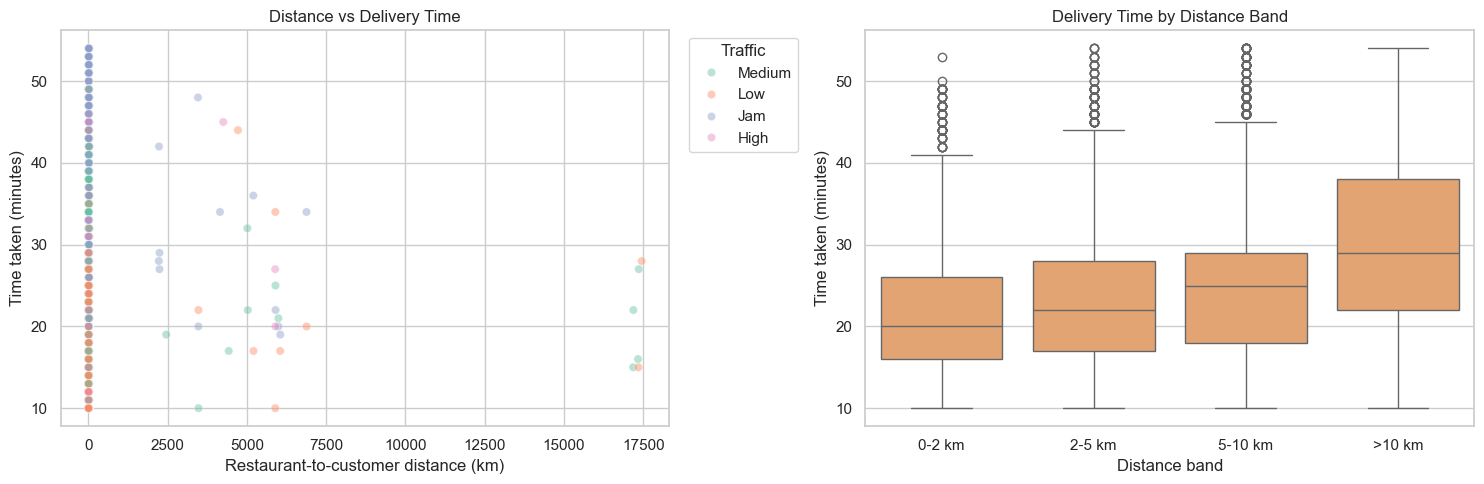

Distance range: 1.47 to 19692.67 km
Pearson correlation with target: -0.003


In [9]:
def haversine_km(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    delta_lat, delta_lon = lat2 - lat1, lon2 - lon1
    value = np.sin(delta_lat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(delta_lon / 2) ** 2
    return 6371 * 2 * np.arcsin(np.sqrt(value))

analysis_df['distance_km'] = haversine_km(analysis_df['Restaurant_latitude'], analysis_df['Restaurant_longitude'], analysis_df['Delivery_location_latitude'], analysis_df['Delivery_location_longitude'])
plot_df = analysis_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['distance_km', TARGET]).copy()
plot_df['distance_band'] = pd.cut(plot_df['distance_km'], bins=[-np.inf, 2, 5, 10, np.inf], labels=['0-2 km', '2-5 km', '5-10 km', '>10 km'])
plot_sample = plot_df.sample(min(5000, len(plot_df)), random_state=42)
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=plot_sample, x='distance_km', y=TARGET, hue='Road_traffic_density', alpha=0.45, palette='Set2', ax=axes[0])
axes[0].set(title='Distance vs Delivery Time', xlabel='Restaurant-to-customer distance (km)', ylabel='Time taken (minutes)')
axes[0].legend(title='Traffic', bbox_to_anchor=(1.02, 1), loc='upper left')
sns.boxplot(data=plot_df, x='distance_band', y=TARGET, color='#f4a261', ax=axes[1])
axes[1].set(title='Delivery Time by Distance Band', xlabel='Distance band', ylabel='Time taken (minutes)')
fig.tight_layout()
plt.show()
distance_corr = plot_df[['distance_km', TARGET]].corr().iloc[0, 1]
print(f'Distance range: {plot_df.distance_km.min():.2f} to {plot_df.distance_km.max():.2f} km')
print(f'Pearson correlation with target: {distance_corr:.3f}')

The scatter plot tests a linear association while distance bands reveal non-linear shifts and spread. The raw coordinates should also be quality-checked because extreme GPS values can distort distance-based modeling.

## 5. Correlation Heatmap

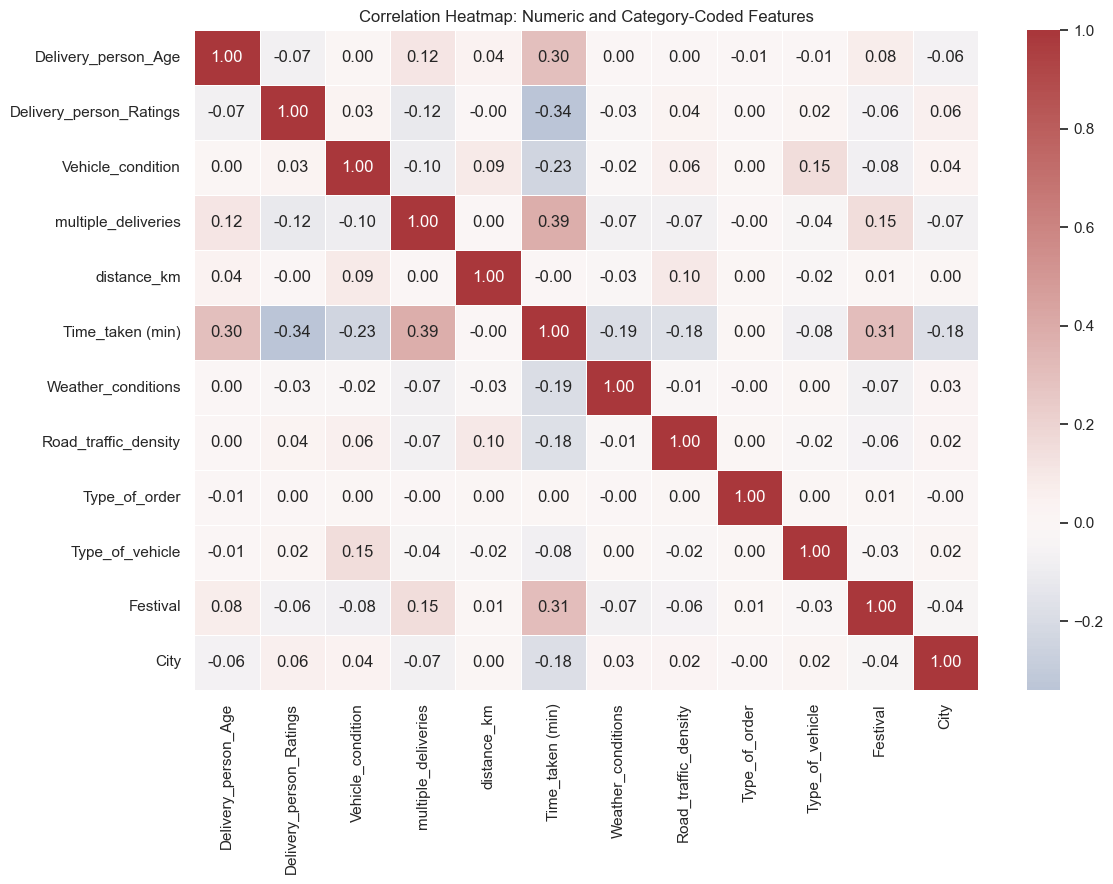

In [10]:
encoded = analysis_df.copy()
for column in CATEGORICAL_COLUMNS:
    encoded[column] = encoded[column].fillna('Missing').astype('category').cat.codes
correlation_columns = ['Delivery_person_Age', 'Delivery_person_Ratings', 'Vehicle_condition', 'multiple_deliveries', 'distance_km', TARGET, *CATEGORICAL_COLUMNS]
correlation = encoded[correlation_columns].corr(numeric_only=True)
plt.figure(figsize=(12, 9))
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='vlag', center=0, linewidths=0.4)
plt.title('Correlation Heatmap: Numeric and Category-Coded Features')
plt.tight_layout()
plt.show()

Integer-coded category correlations are screening signals rather than ordinal truths. Use one-hot encoding and model-based diagnostics for final feature selection.

## 6. Weather and Traffic Interaction

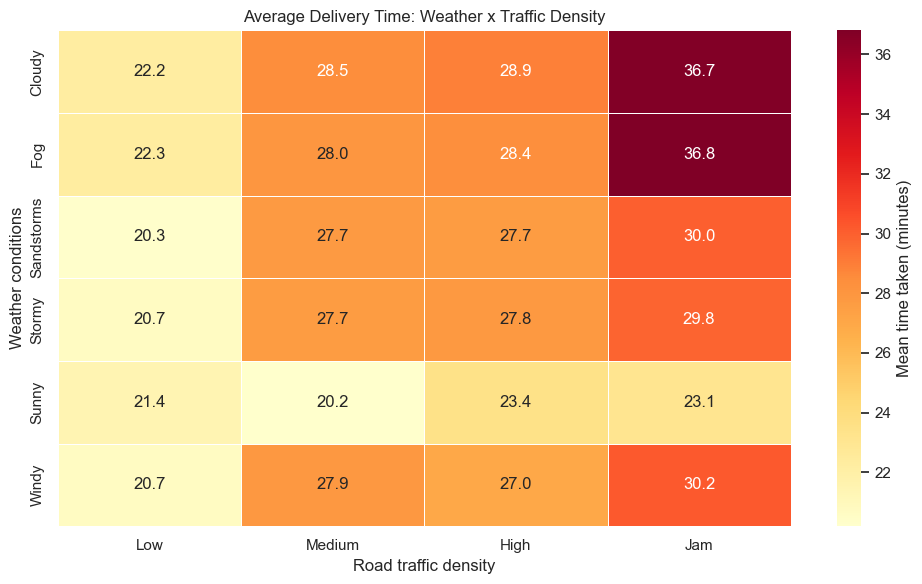

Fastest observed combination: ('Sunny', 'Medium') (20.2 min)
Slowest observed combination: ('Fog', 'Jam') (36.8 min)


In [11]:
interaction = pd.pivot_table(analysis_df, index='Weather_conditions', columns='Road_traffic_density', values=TARGET, aggfunc='mean')
traffic_order = [level for level in ['Low', 'Medium', 'High', 'Jam'] if level in interaction.columns]
interaction = interaction.reindex(columns=traffic_order)
plt.figure(figsize=(10, 6))
sns.heatmap(interaction, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5, cbar_kws={'label': 'Mean time taken (minutes)'})
plt.title('Average Delivery Time: Weather x Traffic Density')
plt.xlabel('Road traffic density')
plt.ylabel('Weather conditions')
plt.tight_layout()
plt.show()
stacked_interaction = interaction.stack()
print(f'Fastest observed combination: {stacked_interaction.idxmin()} ({stacked_interaction.min():.1f} min)')
print(f'Slowest observed combination: {stacked_interaction.idxmax()} ({stacked_interaction.max():.1f} min)')

A cell substantially higher than both its weather-only and traffic-only neighbors suggests compounding delays. Tree interactions or an explicit weather-by-traffic feature can represent this pattern.

## 7. Key Findings and Modeling Implications

In [ ]:
traffic_means = analysis_df.groupby('Road_traffic_density', observed=False)[TARGET].mean()
print(f'- Delivery time skewness is {target.skew():.2f}; compare MAE and RMSE instead of assuming a symmetric target.')
print(f'- IQR identifies {outlier_mask.mean():.1%} target outliers; validate extreme rows before removing potentially real delays.')
print(f'- Traffic means range from {traffic_means.min():.1f} to {traffic_means.max():.1f} minutes, making traffic density a strong candidate feature.')
print(f'- Distance has a Pearson correlation of {distance_corr:.2f} with delivery time; retain it continuously but validate GPS outliers.')
print('- Encode unequal-frequency categories carefully, and use the weather-by-traffic heatmap to justify an interaction feature when combined conditions are consistently slower.')

- Delivery time skewness is 0.49; compare MAE and RMSE instead of assuming a symmetric target.
- IQR identifies 0.6% target outliers; validate extreme rows before removing potentially real delays.
- Traffic means range from 21.3 to 31.2 minutes, making traffic density a strong candidate feature.
- Distance has a Pearson correlation of -0.00 with delivery time; retain it continuously but validate GPS outliers.
- Encode unequal-frequency categories carefully, and use the weather-by-traffic heatmap to justify an interaction feature when combined conditions are consistently slower.


These findings are descriptive rather than causal. Before training, use leakage-safe preprocessing, appropriate validation, and compare a linear baseline with a model that captures non-linear distance and weather-traffic interactions.